In [211]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("../data/raw/telco_churn.csv")

print("Размер таблицы:", df.shape)
df.head()

Размер таблицы: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [212]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [213]:
print("Пропуски:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nРаспределение Churn:")
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True).round(3))

Пропуски:
Series([], dtype: int64)

Распределение Churn:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


In [214]:
# TotalCharges - число (пробелы станут NaN)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Churn - 0/1
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Проверяем, что получилось
print("Тип TotalCharges:", df["TotalCharges"].dtype)
print("Тип Churn:", df["Churn"].dtype)
print("Пропусков в TotalCharges:", df["TotalCharges"].isnull().sum())

Тип TotalCharges: float64
Тип Churn: int64
Пропусков в TotalCharges: 11


In [215]:
df[df["TotalCharges"].isnull()][["tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,NaN,0
753,0,20.25,NaN,0
936,0,80.85,NaN,0
1082,0,25.75,NaN,0
1340,0,56.05,NaN,0
3331,0,19.85,NaN,0
3826,0,25.35,NaN,0
4380,0,20.00,NaN,0
5218,0,19.70,NaN,0
6670,0,73.35,NaN,0


In [216]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)
print("Пропусков теперь:", df["TotalCharges"].isnull().sum())

Пропусков теперь: 0


In [217]:
contract_churn = df.groupby("Contract")["Churn"].agg(["mean", "count"])
contract_churn.columns = ["churn_rate", "n_customers"]
contract_churn["churn_rate"] = contract_churn["churn_rate"].round(3)
print(contract_churn)

                churn_rate  n_customers
Contract                               
Month-to-month       0.427         3875
One year             0.113         1473
Two year             0.028         1695


C:\Users\smila\AppData\Local\Temp\ipykernel_29472\2646071316.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Contract", y="Churn", errorbar=None, palette="Reds_r")


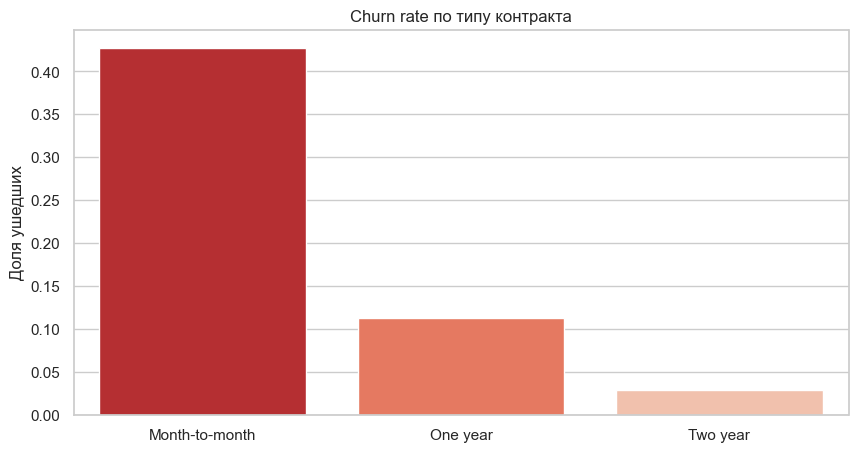

In [218]:
sns.barplot(data=df, x="Contract", y="Churn", errorbar=None, palette="Reds_r")
plt.title("Churn rate по типу контракта")
plt.ylabel("Доля ушедших")
plt.xlabel("")
plt.savefig("../reports/figures/churn_by_contract.png", dpi=150, bbox_inches="tight")
plt.show()

In [219]:
df["tenure_bucket"] = pd.cut(
    df["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=["0-6 мес", "6-12 мес", "1-2 года", "2-4 года", "4-6 лет"]
)

tenure_churn = df.groupby("tenure_bucket", observed=True)["Churn"].agg(["mean", "count"])
tenure_churn["mean"] = tenure_churn["mean"].round(3)
print(tenure_churn)

                mean  count
tenure_bucket              
0-6 мес        0.529   1481
6-12 мес       0.359    705
1-2 года       0.287   1024
2-4 года       0.204   1594
4-6 лет        0.095   2239


C:\Users\smila\AppData\Local\Temp\ipykernel_29472\531539615.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="tenure_bucket", y="Churn", errorbar=None, palette="Blues_r")


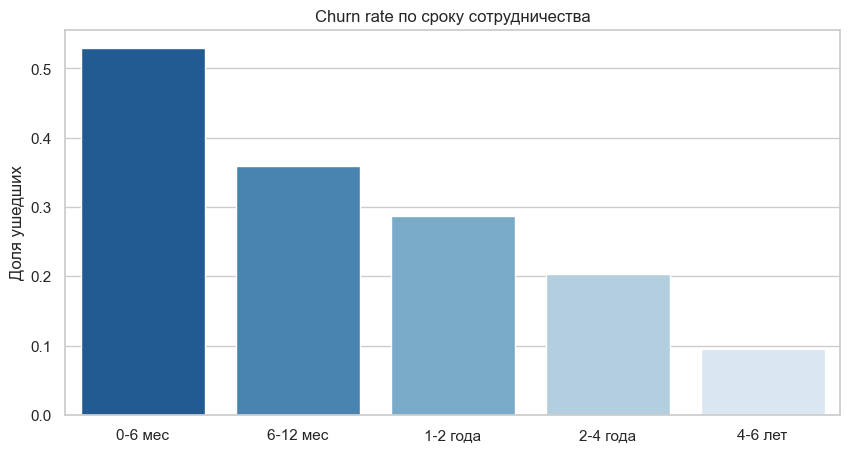

In [220]:
sns.barplot(data=df, x="tenure_bucket", y="Churn", errorbar=None, palette="Blues_r")
plt.title("Churn rate по сроку сотрудничества")
plt.ylabel("Доля ушедших")
plt.xlabel("")
plt.savefig("../reports/figures/churn_by_tenure.png", dpi=150, bbox_inches="tight")
plt.show()

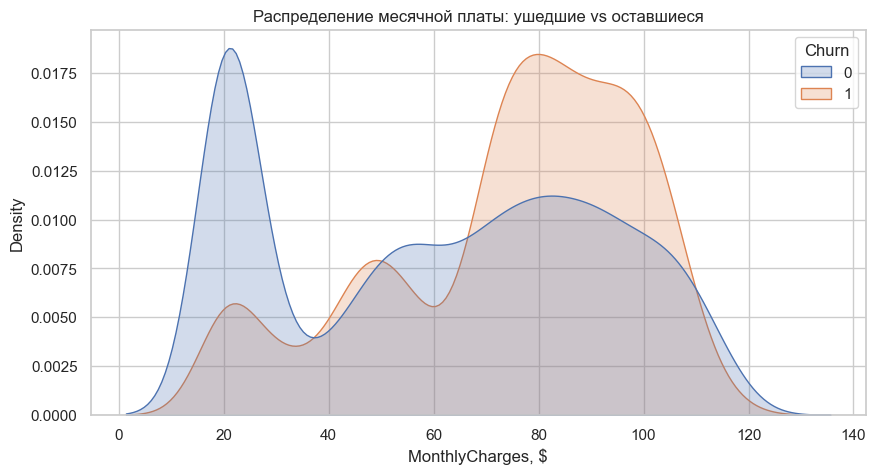

In [221]:
sns.kdeplot(data=df, x="MonthlyCharges", hue="Churn", fill=True, common_norm=False)
plt.title("Распределение месячной платы: ушедшие vs оставшиеся")
plt.xlabel("MonthlyCharges, $")
plt.savefig("../reports/figures/churn_by_monthlycharges.png", dpi=150, bbox_inches="tight")
plt.show()

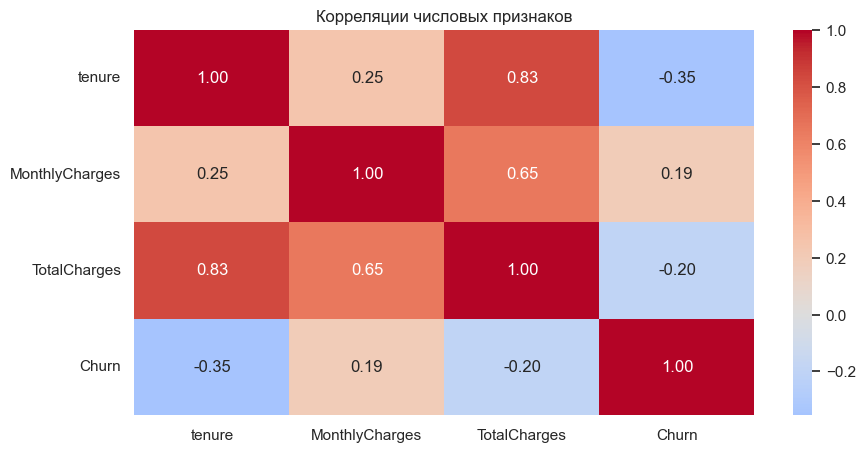

In [222]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Корреляции числовых признаков")
plt.savefig("../reports/figures/correlation.png", dpi=150, bbox_inches="tight")
plt.show()

In [223]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

# Отделяем признаки от таргета
X = df.drop(columns=["customerID", "Churn", "tenure_bucket"])
y = df["Churn"]

# Определяем числовые и категориальные колонки
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Числовые:", num_cols)
print("Категориальные:", cat_cols)

Числовые: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Категориальные: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [224]:
# Препроцессор: числа → стандартизация, категории → one-hot
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), cat_cols),
])

# Пайплайн: препроцессор + логистическая регрессия
model = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
])

# Train/test split (стратифицированный — сохраняет пропорцию классов)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Обучение
model.fit(X_train, y_train)

# Предсказание вероятностей
y_proba = model.predict_proba(X_test)[:, 1]

# Метрика
auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC на тесте: {auc:.4f}")
print()
print(classification_report(y_test, (y_proba >= 0.5).astype(int), digits=3))

ROC-AUC на тесте: 0.8417

              precision    recall  f1-score   support

           0      0.902     0.723     0.803      1035
           1      0.505     0.783     0.614       374

    accuracy                          0.739      1409
   macro avg      0.704     0.753     0.708      1409
weighted avg      0.797     0.739     0.753      1409



In [225]:
# Достаём названия признаков после one-hot
feature_names = (num_cols 
                 + list(model.named_steps["prep"]
                        .named_transformers_["cat"]
                        .get_feature_names_out(cat_cols)))

# Коэффициенты логистической регрессии
coefs = pd.DataFrame({
    "feature": feature_names,
    "coef": model.named_steps["clf"].coef_[0],
}).sort_values("coef", key=abs, ascending=False)

print(coefs.head(15).to_string(index=False))

                       feature      coef
             Contract_Two year -1.402888
   InternetService_Fiber optic  1.226756
                        tenure -1.161230
             Contract_One year -0.714122
                MonthlyCharges -0.555431
                  TotalCharges  0.491548
           StreamingMovies_Yes  0.422020
PaymentMethod_Electronic check  0.404254
               StreamingTV_Yes  0.397873
              PhoneService_Yes -0.344938
          PaperlessBilling_Yes  0.337532
            OnlineSecurity_Yes -0.334712
             MultipleLines_Yes  0.326054
               TechSupport_Yes -0.266696
                Dependents_Yes -0.231152


In [226]:
from xgboost import XGBClassifier

# Считаем соотношение классов для балансировки
scale = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = Pipeline([
    ("prep", preprocessor),
    ("clf", XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale,
        eval_metric="auc",
        random_state=42,
        n_jobs=-1,
    )),
])

xgb_model.fit(X_train, y_train)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

auc_xgb = roc_auc_score(y_test, y_proba_xgb)
print(f"XGBoost ROC-AUC: {auc_xgb:.4f}")
print(f"LogReg ROC-AUC:  {auc:.4f}")
print(f"Прирост:         +{auc_xgb - auc:.4f}")

XGBoost ROC-AUC: 0.8353
LogReg ROC-AUC:  0.8417
Прирост:         +-0.0064


In [227]:
import shap

# Достаём обученный XGBoost из пайплайна
xgb_clf = xgb_model.named_steps["clf"]
prep = xgb_model.named_steps["prep"]

# Трансформируем тестовые данные (one-hot уже применён)
X_test_transformed = prep.transform(X_test)

# Имена признаков после трансформации
feature_names = (num_cols 
                 + list(prep.named_transformers_["cat"]
                        .get_feature_names_out(cat_cols)))

# Считаем SHAP-значения
explainer = shap.TreeExplainer(xgb_clf)
shap_values = explainer.shap_values(X_test_transformed)
print("SHAP values shape:", shap_values.shape)

SHAP values shape: (1409, 30)


In [228]:
# Средняя абсолютная важность по всем тестовым примерам
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": mean_abs_shap,
}).sort_values("mean_abs_shap", ascending=False).head(15)

print(shap_importance.to_string(index=False))

                       feature  mean_abs_shap
             Contract_Two year       0.680938
                        tenure       0.593302
                MonthlyCharges       0.409681
                  TotalCharges       0.344456
   InternetService_Fiber optic       0.324885
             Contract_One year       0.316342
PaymentMethod_Electronic check       0.188827
            OnlineSecurity_Yes       0.143876
          PaperlessBilling_Yes       0.139880
               TechSupport_Yes       0.139828
             MultipleLines_Yes       0.123178
           StreamingMovies_Yes       0.098420
               StreamingTV_Yes       0.092499
            InternetService_No       0.084261
                Dependents_Yes       0.075068


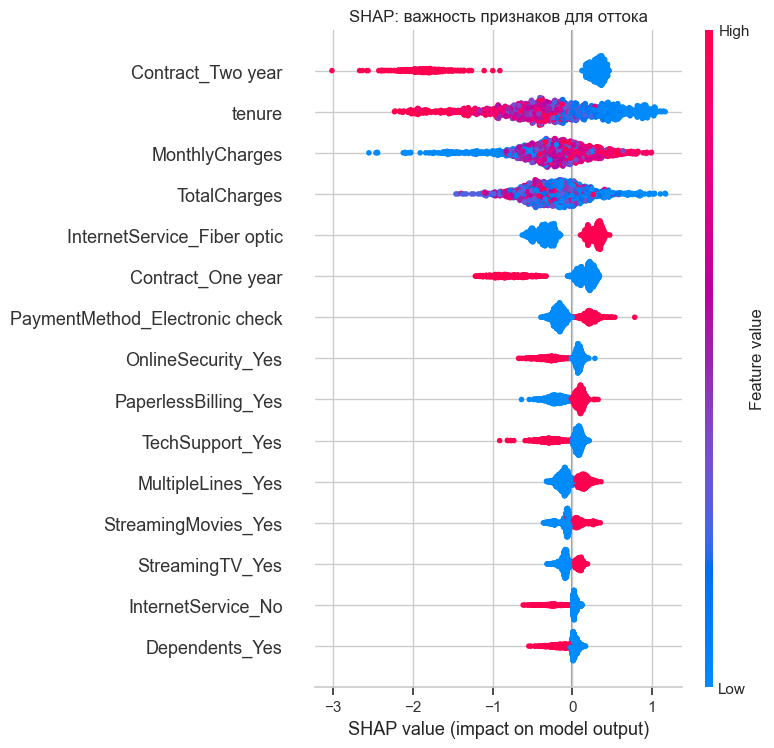

In [229]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    max_display=15,
    show=False,
)
plt.title("SHAP: важность признаков для оттока")
plt.savefig("../reports/figures/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

In [230]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_proba_xgb)

# Смотрим, что даёт топ-20% по риску
n_top = int(len(y_test) * 0.2)
idx_top = np.argsort(y_proba_xgb)[::-1][:n_top]

churn_rate_top = y_test.iloc[idx_top].mean()
churn_rate_all = y_test.mean()

print(f"Churn rate в целом по выборке:    {churn_rate_all:.1%}")
print(f"Churn rate в топ-20% по риску:    {churn_rate_top:.1%}")
print(f"Lift@20%:                          {churn_rate_top / churn_rate_all:.2f}x")

Churn rate в целом по выборке:    26.5%
Churn rate в топ-20% по риску:    65.8%
Lift@20%:                          2.48x


In [231]:
# Допущения (реалистичные для телекома)
LTV = 1500         # сколько теряем с ушедшего клиента
OFFER_COST = 50    # стоимость оффера удержания
UPLIFT_RATE = 0.3  # 30% тех, кто собирался уйти, остаются после оффера

# Кампания на топ-20% риска
n_customers = n_top
at_risk = y_test.iloc[idx_top].sum()  # сколько реально ушло бы
saved = at_risk * UPLIFT_RATE          # сколько удержали
revenue_saved = saved * LTV
campaign_cost = n_customers * OFFER_COST
net_profit = revenue_saved - campaign_cost

print(f"Клиентов в кампании:    {n_customers}")
print(f"Из них ушли бы:         {int(at_risk)}")
print(f"Удержали благодаря:     {saved:.1f}")
print(f"Спасённая выручка:      ${revenue_saved:,.0f}")
print(f"Стоимость кампании:     ${campaign_cost:,.0f}")
print(f"Чистая прибыль:         ${net_profit:,.0f}")
print(f"ROI:                    {net_profit / campaign_cost:.2f}x")

Клиентов в кампании:    281
Из них ушли бы:         185
Удержали благодаря:     55.5
Спасённая выручка:      $83,250
Стоимость кампании:     $14,050
Чистая прибыль:         $69,200
ROI:                    4.93x
